In [1]:
### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import h5py

## Read the Dust dataset

In [6]:
import xarray as xr
import pandas as pd

fn = "/data/shared_data/DustProf_Proestakis/2007/Fine-Mode_Coarse-Mode_Pure-Dust-V1-CAL_LID_L2_05km-V4-21.2007-04-14T03-56-59ZN.nc"

groups = [
    "Geolocation",
    "Flags_and_Auxiliary",
    "EO4AQ-DustFM_Product/Backscatter_Coefficient_532",
    "EO4AQ-DustFM_Product/Extinction_Coefficient_532",
    "EO4AQ-DustFM_Product/Mass_Concentration",
]

ds_final = xr.merge([xr.open_dataset(fn, group=g) for g in groups])

raw_time = ds_final.Profile_UTC_Time.values
date_int = (raw_time // 1).astype(int) + 20000000
dt_series = (
    pd.to_datetime(date_int.astype(str), format="%Y%m%d")
    + pd.to_timedelta(raw_time % 1, unit="D")
)

ds_ = ds_final.assign_coords(
    time=("CAL_L2_5km_Pro", dt_series),
    lat=("CAL_L2_5km_Pro", ds_final.Latitude.values),
    lon=("CAL_L2_5km_Pro", ds_final.Longitude.values),
    height=("Alt", ds_final.Height.values),
).drop_vars(
    ["Profile_UTC_Time", "Latitude", "Longitude", "Height"]
)

ds_


<xarray.Dataset> Size: 40MB
Dimensions:                                       (CAL_L2_5km_Pro: 3148,
                                                   Alt: 399)
Coordinates:
    time                                          (CAL_L2_5km_Pro) datetime64[ns] 25kB ...
    lat                                           (CAL_L2_5km_Pro) float32 13kB ...
    lon                                           (CAL_L2_5km_Pro) float32 13kB ...
    height                                        (Alt) float64 3kB 29.84 ......
Dimensions without coordinates: CAL_L2_5km_Pro, Alt
Data variables:
    Day_Night_Flag                                (CAL_L2_5km_Pro) float32 13kB ...
    AVD_Aerosol_Subtype                           (CAL_L2_5km_Pro, Alt) float32 5MB ...
    AVD_Feature_Type                              (CAL_L2_5km_Pro, Alt) float32 5MB ...
    Surface_Elevation                             (CAL_L2_5km_Pro) float32 13kB ...
    Pure_Dust_Fine_Backscatter_Coefficient_532    (CAL_L2_5km_Pro, Alt) float32 5MB ...
    Pure_Dust_Coarse_Backscatter_Coefficient_532  (CAL_L2_5km_Pro, Alt) float32 5MB ...
    Pure_Dust_Fine_Extinction_Coefficient_532     (CAL_L2_5km_Pro, Alt) float32 5MB ...
    Pure_Dust_Coarse_Extinction_Coefficient_532   (CAL_L2_5km_Pro, Alt) float32 5MB ...
    Pure_Dust_Fine_Mass_Concentration             (CAL_L2_5km_Pro, Alt) float32 5MB ...
    Pure_Dust_Coarse_Mass_Concentration           (CAL_L2_5km_Pro, Alt) float32 5MB ...

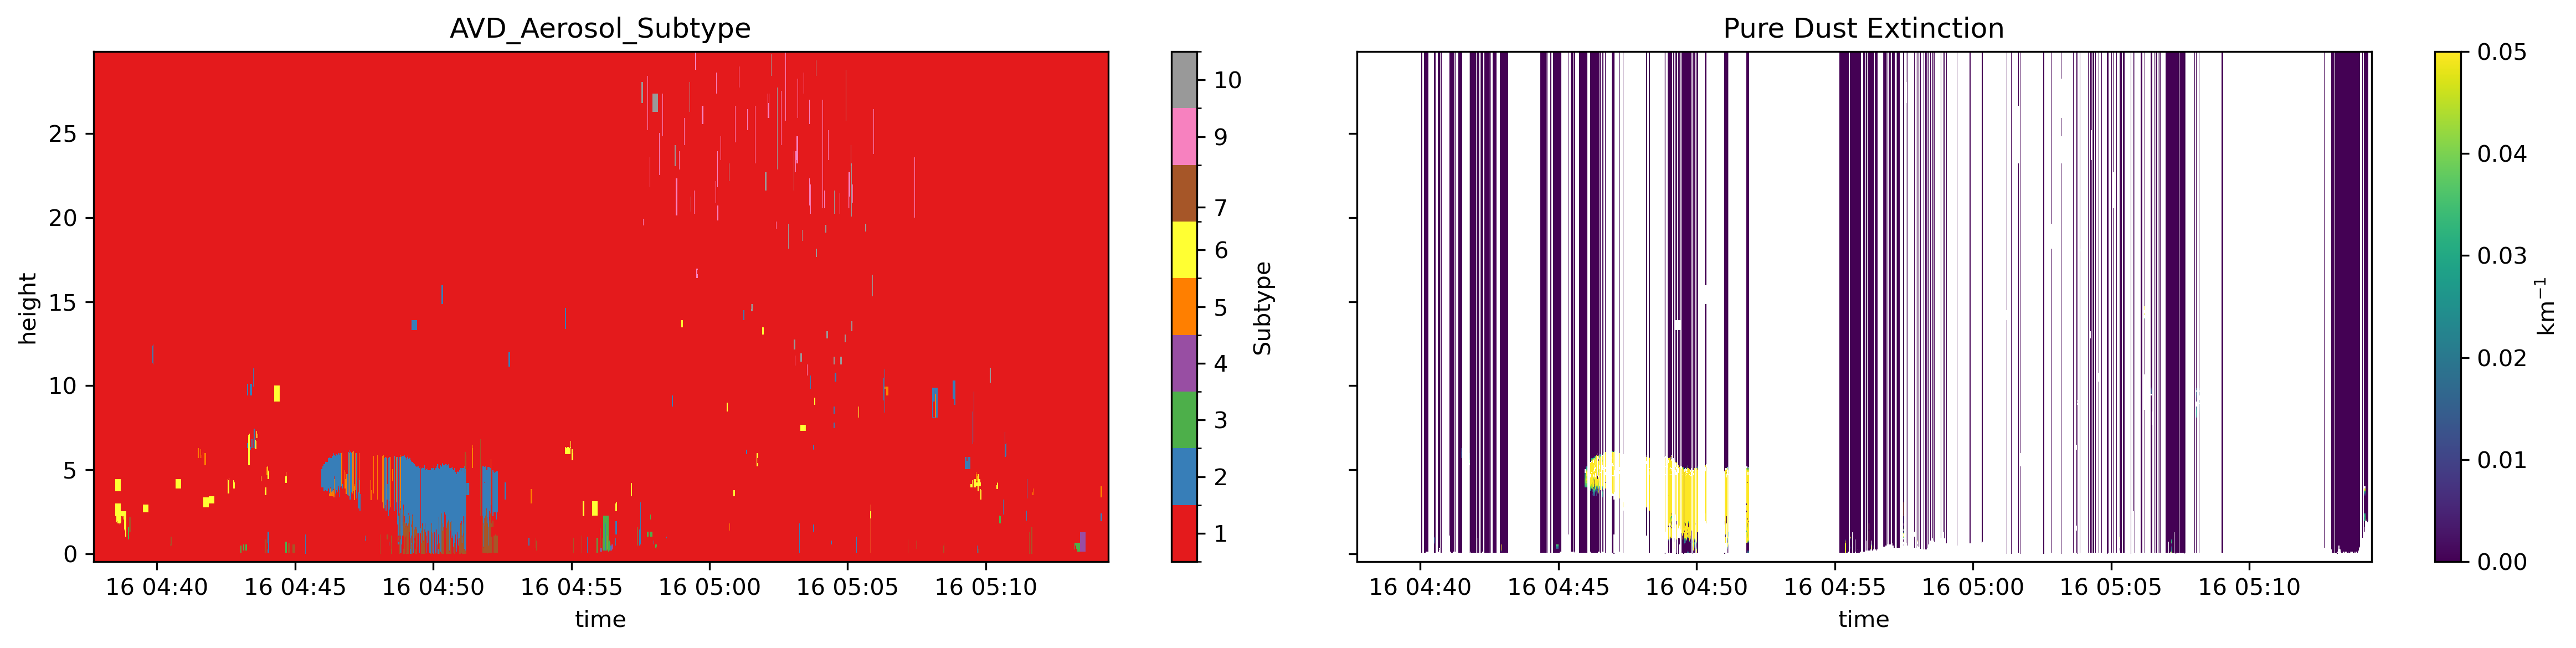

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import get_cmap

x_dim, z_dim = "CAL_L2_5km_Pro", "Alt"

sub2 = ds_["AVD_Aerosol_Subtype"].transpose(x_dim, z_dim).values
ext2 = (
    ds_["Pure_Dust_Fine_Extinction_Coefficient_532"]
  + ds_["Pure_Dust_Coarse_Extinction_Coefficient_532"]
).transpose(x_dim, z_dim).values
ext2m = np.ma.masked_where(ext2 <= 0, ext2)
x, y = ds_["time"].values, ds_["height"].values

subs = np.unique(sub2[sub2 > 0])
cmap = ListedColormap(get_cmap("Set1", len(subs)).colors)
norm = BoundaryNorm(np.r_[subs - 0.5, subs[-1] + 0.5], cmap.N)

fig, ax = plt.subplots(1, 2, figsize=(16, 4), sharey=True, dpi=300)

pcm0 = ax[0].pcolormesh(x, y, sub2.T, cmap=cmap, norm=norm, shading="nearest")
ax[0].set_title("AVD_Aerosol_Subtype")
ax[0].set_xlabel("time")
ax[0].set_ylabel("height")
fig.colorbar(pcm0, ax=ax[0], ticks=subs, label="Subtype")

pcm1 = ax[1].pcolormesh(x, y, ext2.T, shading="auto", vmin=0, vmax=0.05, cmap="viridis",)
ax[1].set_title("Pure Dust Extinction")
ax[1].set_xlabel("time")
fig.colorbar(pcm1, ax=ax[1], label="km$^{-1}$")

plt.tight_layout()
plt.show()


In [16]:
subs = np.unique(sub2[sub2 > 0])
tot  = np.nansum(ext2[sub2 > 0])

for s in subs:
    frac = np.nansum(ext2[sub2 == s]) / tot
    print(f"Subtype {int(s)}: {frac:.2%}")


Subtype 1: 0.00%
Subtype 2: 92.84%
Subtype 3: 0.00%
Subtype 4: 0.00%
Subtype 5: 2.50%
Subtype 6: 0.00%
Subtype 7: 4.04%
Subtype 9: 0.61%
Subtype 10: 0.00%


In [17]:
mask = (sub2 > 0) & (ext2 > 0)
tot  = np.nansum(ext2[mask])

for s in np.unique(sub2[mask]):
    frac = np.nansum(ext2[(sub2 == s) & mask]) / tot
    print(f"Subtype {int(s)}: {frac:.2%}")


Subtype 2: 92.84%
Subtype 5: 2.50%
Subtype 7: 4.04%
Subtype 9: 0.61%
Subtype 10: 0.00%


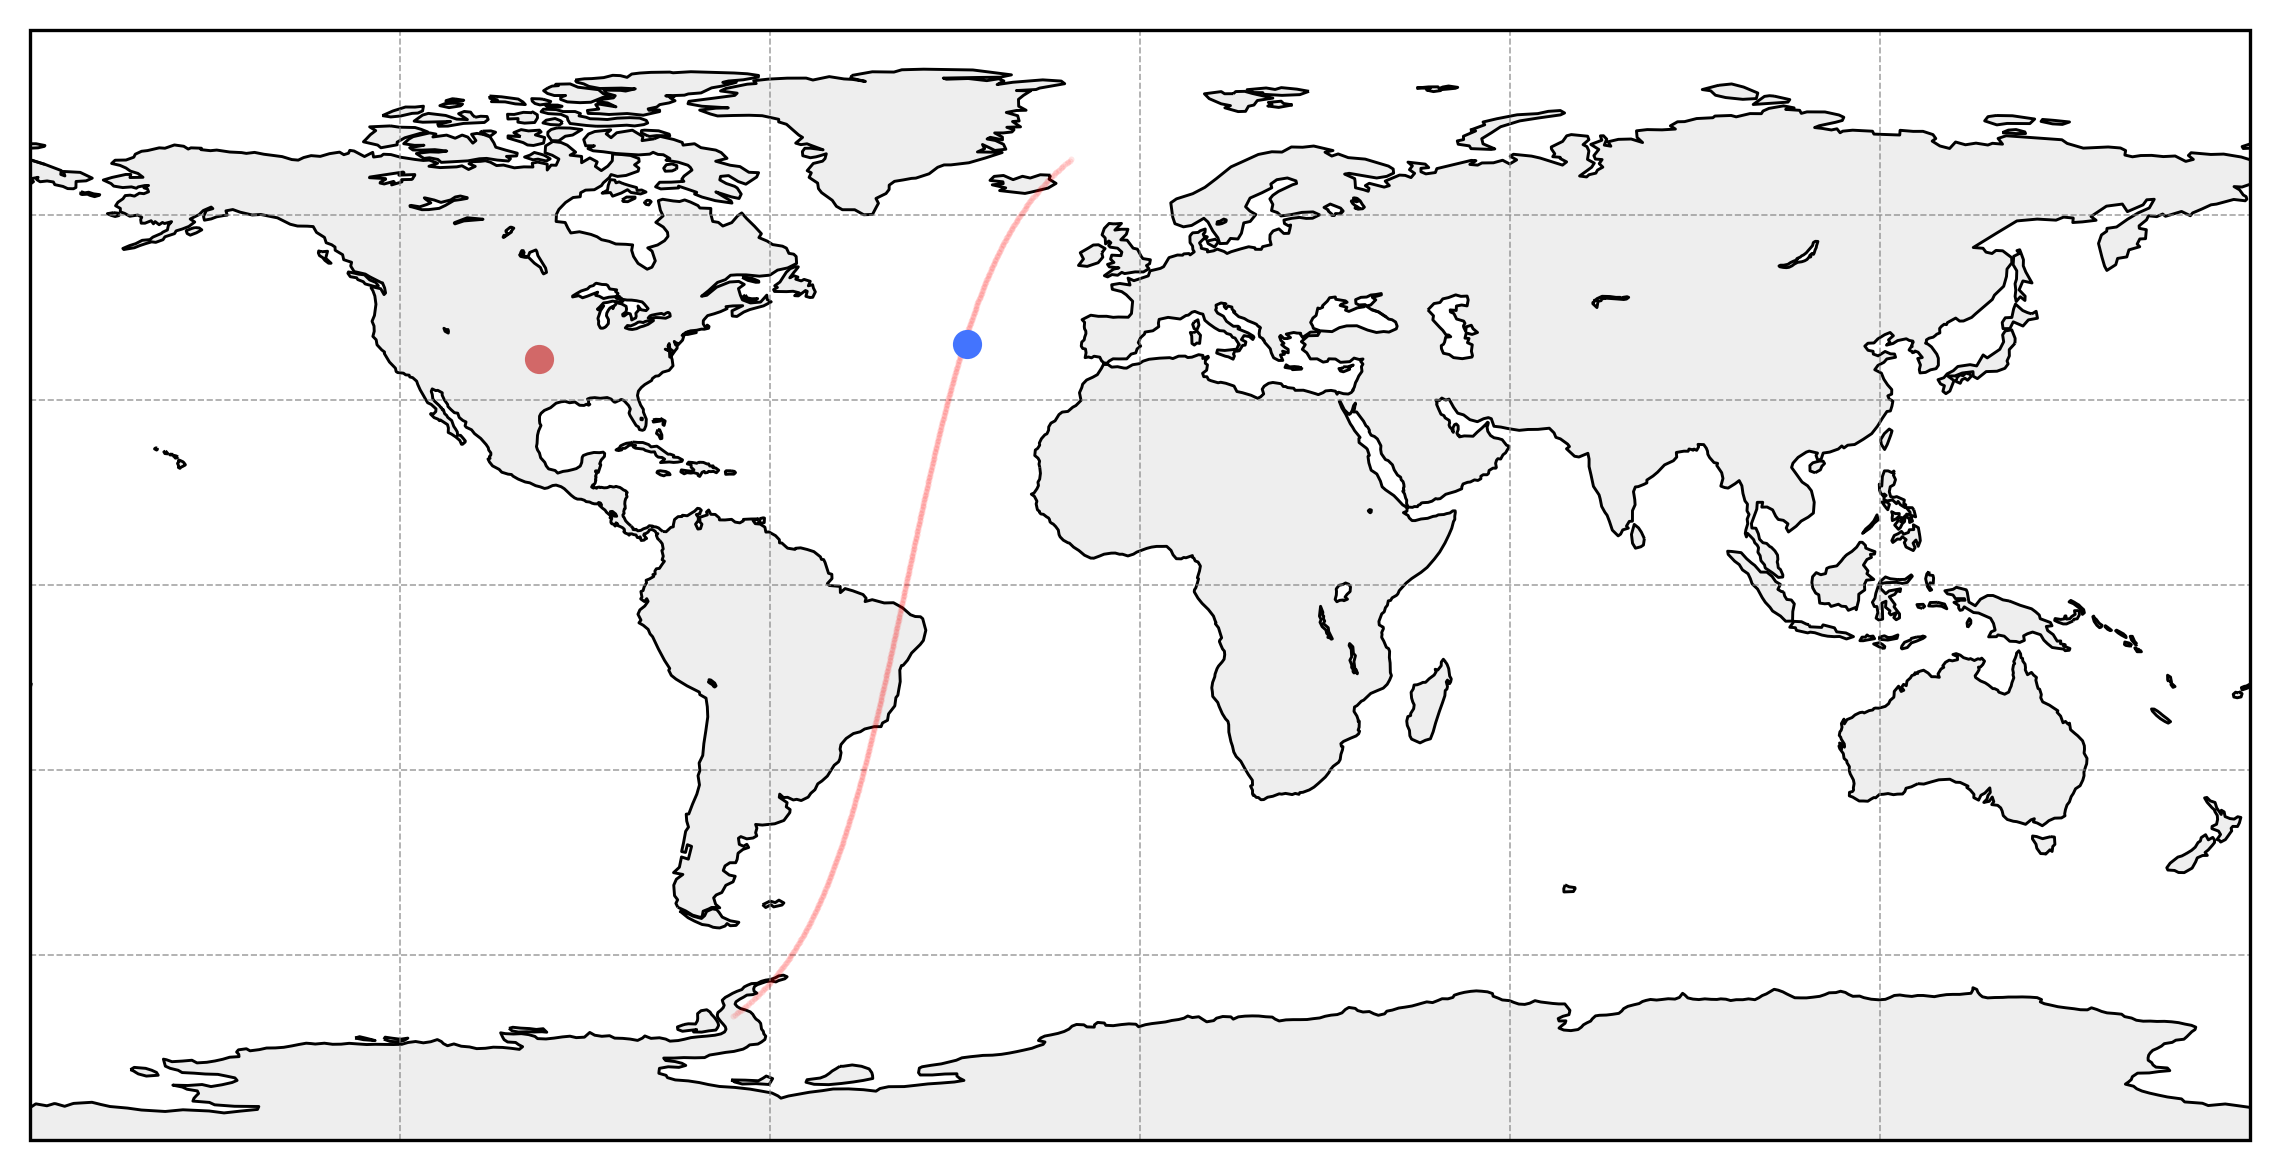

In [7]:
import numpy as np, matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature
from matplotlib.patches import Rectangle

lat_ena, lon_ena = 39.0916, -28.0257; lat_sgp, lon_sgp = 36.607322, -97.487643
lat = ds_.lat.values; lon = ((ds_.lon.values + 180) % 360) - 180

fig, ax = plt.subplots(figsize=(10,4), dpi=300, subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.add_feature(cfeature.OCEAN.with_scale('110m'), facecolor='#fff'); ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor='#eee')
ax.add_feature(cfeature.COASTLINE.with_scale('110m'), lw=0.7); ax.add_feature(cfeature.LAKES.with_scale('110m'), facecolor='#fff', edgecolor='k', lw=0.7)
ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', linestyle='--', alpha=0.7)

ax.scatter(lon[::5], lat[::5], s=0.2, c='r', alpha=0.1, transform=ccrs.PlateCarree(), zorder=3)
ax.plot(lon_ena, lat_ena, 'o', c='#4374fe', ms=6, transform=ccrs.PlateCarree(), zorder=5)
ax.plot(lon_sgp, lat_sgp, 'o', c='#d26868', ms=6, transform=ccrs.PlateCarree(), zorder=5)
ax.add_patch(Rectangle((lon_ena-0.5, lat_ena-0.5), 1, 1, ec='#4374fe', fc='none', lw=1.2, transform=ccrs.PlateCarree(), zorder=4))
ax.add_patch(Rectangle((lon_sgp-0.5, lat_sgp-0.5), 1, 1, ec='#d26868', fc='none', lw=1.2, transform=ccrs.PlateCarree(), zorder=4))

ax.set_extent([-180,180,-90,90]); plt.tight_layout(); plt.show()


## Pick the data over ENA and SGP region

In [2]:
import glob, os, numpy as np, xarray as xr, pandas as pd

base_in = "/data/shared_data/DustProf_Proestakis"
out_ena = "/data/ggong/CALIPSO/Dustprof/ENA_5x5"
out_sgp = "/data/ggong/CALIPSO/Dustprof/SGP_5x5"
os.makedirs(out_ena, exist_ok=True); os.makedirs(out_sgp, exist_ok=True)

groups = [
    "Geolocation",
    "Flags_and_Auxiliary",
    "EO4AQ-DustFM_Product/Backscatter_Coefficient_532",
    "EO4AQ-DustFM_Product/Extinction_Coefficient_532",
    "EO4AQ-DustFM_Product/Mass_Concentration",
]

ENA = (36.5916, 41.5916, -30.5257, -25.5257)
SGP = (34.107322, 39.107322, -99.987643, -94.987643)
def build_pretty(fn):
    dss = [xr.open_dataset(fn, group=g) for g in groups]
    ds = xr.merge(dss)
    for d in dss: d.close()
    rt = ds.Profile_UTC_Time.values
    di = (rt // 1).astype(int) + 20000000
    dt = pd.to_datetime(di.astype(str), format="%Y%m%d") + pd.to_timedelta(rt % 1, unit="D")
    return ds.assign_coords(
        time=("CAL_L2_5km_Pro", dt),
        lat=("CAL_L2_5km_Pro", ds.Latitude.values),
        lon=("CAL_L2_5km_Pro", ds.Longitude.values),
        height=("Alt", ds.Height.values),
    ).drop_vars(["Profile_UTC_Time", "Latitude", "Longitude", "Height"])

def save_box(ds, box, outdir, stem):
    latmin, latmax, lonmin, lonmax = box
    idx = np.where(
        (ds.lat >= latmin) & (ds.lat <= latmax) &
        (ds.lon >= lonmin) & (ds.lon <= lonmax)
    )[0]
    if idx.size:
        ds.isel(CAL_L2_5km_Pro=idx).to_netcdf(os.path.join(outdir, stem + ".nc"))

files = sorted(sum([glob.glob(f"{base_in}/{y}/*.nc") for y in range(2006, 2022)], []))
bad = []

for fn in files:
    try:
        stem = os.path.basename(fn).replace(".nc", "")
        ds = build_pretty(fn)
        save_box(ds, ENA, out_ena, stem + ".ENA")
        save_box(ds, SGP, out_sgp, stem + ".SGP")
        ds.close()
    except Exception:
        bad.append(fn)
        print("SKIP:", fn)

print("Done. Bad files:", len(bad))


SKIP: /data/shared_data/DustProf_Proestakis/2011/Fine-Mode_Coarse-Mode_Pure-Dust-V1-CAL_LID_L2_05km-V4-21.2011-08-29T10-44-18ZN.nc
SKIP: /data/shared_data/DustProf_Proestakis/2021/Fine-Mode_Coarse-Mode_Pure-Dust-V1-CAL_LID_L2_05km-V4-21.2021-03-09T22-04-51ZN.nc
Done. Bad files: 2


## original CALIPSO

In [12]:
from pyhdf.SD import SD, SDC

fn = "/data/shared_data/satellite_data/CALIPSO/daily/L2_05km-V4-51/ENA/APro/CAL_LID_L2_05kmAPro-Standard-V4-51.2023-06-20T02-31-37ZD.hdf"

sd = SD(fn, SDC.READ)

print("SDS variables:")
for name in sd.datasets().keys():
    print(name)

sd.end()


SDS variables:
Profile_ID
Latitude
Longitude
Profile_Time
Profile_UTC_Time
Day_Night_Flag
Minimum_Laser_Energy_532
Column_Optical_Depth_Cloud_532
Column_Optical_Depth_Cloud_Uncertainty_532
Column_Optical_Depth_Tropospheric_Aerosols_532
Column_Optical_Depth_Tropospheric_Aerosols_Uncertainty_532
Column_Optical_Depth_Stratospheric_Aerosols_532
Column_Optical_Depth_Stratospheric_Aerosols_Uncertainty_532
Column_Optical_Depth_Tropospheric_Aerosols_1064
Column_Optical_Depth_Tropospheric_Aerosols_Uncertainty_1064
Column_Optical_Depth_Stratospheric_Aerosols_1064
Column_Optical_Depth_Stratospheric_Aerosols_Uncertainty_1064
Column_Feature_Fraction
Column_Integrated_Attenuated_Backscatter_532
Column_IAB_Cumulative_Probability
Tropopause_Height
Tropopause_Temperature
Temperature
Pressure
Molecular_Number_Density
Ozone_Number_Density
Relative_Humidity
IGBP_Surface_Type
Surface_Elevation_Statistics
Surface_Wind_Speeds_02m
Samples_Averaged
Aerosol_Layer_Fraction
Cloud_Layer_Fraction
Atmospheric_Volume